# Research Swarm Interactive Notebook

This notebook allows interactive experimentation with the Research Strategist and Technical Researcher agents.

## Workflow
1. **Research Strategist** - Analyzes topic and creates content brief
2. **Transfer** - Hands off to Technical Researcher
3. **Technical Researcher** - Gathers detailed information via web search

In [1]:
# Cell 1: Environment Setup
from dotenv import load_dotenv
import json
import uuid

load_dotenv()

True

In [3]:
# Cell 2: Load Style Reference
with open('prompts/style_reference.json', 'r', encoding='utf-8') as f:
    style_reference = json.load(f)

print("📋 Style Reference Loaded:")
print(f"Name: {style_reference['name']}")
print(f"Primary Language: {style_reference['language']['primary']}")
print(f"Target Audience: {style_reference['audience']['profile']}")
print(f"\nStyle DNA: {', '.join(style_reference['tone']['overall'])}")

📋 Style Reference Loaded:
Name: Liam Tech Talk Explainer
Primary Language: vi-VN
Target Audience: VN tech learners/engineers

Style DNA: gần gũi, thực tế, giải thích cặn kẽ, nhiệt tình


In [6]:
# Cell 3: Import Research Agents
import sys
sys.path.insert(0, '..')

from agents.research_strategist import create_research_strategist_agent
from agents.research_technical import create_research_technical_agent
from config.agent_names import RESEARCH_STRATEGIST, RESEARCH_TECHNICAL

print("✅ Research agents imported successfully")
print(f"Agent 1: {RESEARCH_STRATEGIST}")
print(f"Agent 2: {RESEARCH_TECHNICAL}")

✅ Research agents imported successfully
Agent 1: research_strategist
Agent 2: research_technical


In [7]:
# Cell 4: Create Swarm
from langgraph.checkpoint.memory import MemorySaver
from langgraph_swarm import create_swarm

# Create both research agents
print("🔧 Creating Research Strategist agent...")
strategist_agent = create_research_strategist_agent()

print("🔧 Creating Technical Researcher agent...")
technical_agent = create_research_technical_agent()

# Create the swarm
print("\n🔗 Creating Research Swarm...")
swarm = create_swarm(
    agents=[strategist_agent, technical_agent],
    default_active_agent=RESEARCH_STRATEGIST,
)

# Compile with checkpointer
checkpointer = MemorySaver()
app = swarm.compile(checkpointer=checkpointer)

print("\n✅ Research Swarm created and compiled!")
print(f"Default active agent: {RESEARCH_STRATEGIST}")

🔧 Creating Research Strategist agent...
🔧 Creating Technical Researcher agent...

🔗 Creating Research Swarm...

✅ Research Swarm created and compiled!
Default active agent: research_strategist


📊 Research Swarm Agent Graph:


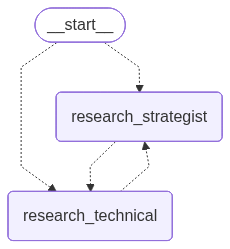

In [8]:
# Cell 5: Visualize Agent Graph
from IPython.display import Image, display

print("📊 Research Swarm Agent Graph:")
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
# Cell 6: Helper Function - Pretty Print Stream
def print_stream(stream):
    """Pretty print agent interactions with visual formatting."""
    for ns, update in stream:
        for node, node_updates in update.items():
            if node_updates is None:
                continue

            if isinstance(node_updates, (dict, tuple)):
                node_updates_list = [node_updates]
            elif isinstance(node_updates, list):
                node_updates_list = node_updates
            else:
                raise ValueError(node_updates)

            for node_updates in node_updates_list:
                if isinstance(node_updates, tuple):
                    continue
                messages_key = next(
                    (k for k in node_updates.keys() if "messages" in k), None
                )
                if messages_key is not None:
                    node_updates[messages_key][-1].pretty_print()
                else:
                    pass

print("✅ Helper function defined: print_stream()")

✅ Helper function defined: print_stream()


In [10]:
# Cell 7: Initialize Session
config = {
    "configurable": {
        "thread_id": str(uuid.uuid4()),
    }
}

print(f"🆔 Session initialized with thread_id: {config['configurable']['thread_id']}")
print("\n💡 Tip: Each cell execution continues the same conversation thread.")
print("💡 To start fresh, re-run this cell to get a new thread_id.")

🆔 Session initialized with thread_id: 988f2d62-c49b-4523-bf21-5db125ac2a97

💡 Tip: Each cell execution continues the same conversation thread.
💡 To start fresh, re-run this cell to get a new thread_id.


## Interactive Experimentation

The cells below allow you to interact with the Research Swarm step-by-step.

In [11]:
# Cell 8: Initial Topic Request - Research Strategist Creates Brief
print("="*80)
print("STEP 1: Research Strategist Creates Content Brief")
print("="*80)
print()

# Create topic request with style reference
topic_request = f"""Create a comprehensive content brief for a Vietnamese technical newsletter on the following topic:

**Topic:** Apache Flink - Real-Time Stream Processing Framework

**Context:**
- Our audience has already read our Kafka article and understands distributed systems basics
- They are Vietnamese developers/data engineers (intermediate to advanced level)
- Previous article maintained casual Vietnamese tone with technical English terms

**Style Reference:**
{json.dumps(style_reference, ensure_ascii=False, indent=2)}

After creating the brief, please transfer to the Technical Researcher to gather the information."""

print_stream(
    app.stream(
        {
            "messages": [
                {"role": "user", "content": topic_request}
            ]
        },
        config,
        subgraphs=True,
    )
)

STEP 1: Research Strategist Creates Content Brief

================================== Ai Message ==================================
Name: research_strategist

---
# CONTENT BRIEF: Apache Flink - Real-Time Stream Processing Framework

## EXECUTIVE SUMMARY
**One-line pitch**: "Apache Flink - Biến dòng dữ liệu liên tục thành thông tin hành động ngay lập tức."
**Why now**: Với sự phát triển nhanh chóng của các công ty thương mại điện tử và fintech tại Việt Nam, nhu cầu xử lý dữ liệu thời gian thực cho các ứng dụng như phát hiện gian lận và phân tích dữ liệu là rất cấp thiết.
**Estimated complexity**: Intermediate to Advanced
**Estimated length**: 2000-2500 words

## TARGET AUDIENCE
**Primary audience**: Vietnamese developers and data engineers with intermediate to advanced experience in distributed systems.
**Assumed knowledge**: 
- Understanding of distributed systems
- Familiarity with Apache Kafka

**Pain points this addresses**:
- Difficulty in processing real-time data efficiently
- C

In [12]:
# Cell 9: Continue Conversation - Provide Additional Guidance
print("="*80)
print("STEP 2: Provide Additional Guidance to Active Agent")
print("="*80)
print()

print_stream(
    app.stream(
        {
            "messages": [
                {
                    "role": "user",
                    "content": "Who are you and what context you currently have?"
                }
            ]
        },
        config,
        subgraphs=True,
    )
)

STEP 2: Provide Additional Guidance to Active Agent

================================== Ai Message ==================================
Name: research_technical

I am the Technical Researcher responsible for gathering comprehensive and accurate technical information for a Vietnamese technical newsletter. My current context involves focusing on the topic of Apache Flink, a real-time stream processing framework. I have received a content brief that outlines the research needs, including official definitions, real-world use cases, performance data, comparisons with similar technologies, and insights from the Vietnamese tech community. My task is to execute research based on this brief to support the writing of an informative and engaging article for Vietnamese developers and data engineers.
================================== Ai Message ==================================
Name: research_technical

I am the Technical Researcher responsible for gathering comprehensive and accurate technical inf

In [13]:
# Cell 10: Ask Follow-up Questions
print("="*80)
print("STEP 3: Ask Follow-up Questions")
print("="*80)
print()

# Modify this message as needed
follow_up = "Can you show me details what context you have right now?"

print_stream(
    app.stream(
        {
            "messages": [
                {"role": "user", "content": follow_up}
            ]
        },
        config,
        subgraphs=True,
    )
)

STEP 3: Ask Follow-up Questions

================================== Ai Message ==================================
Name: research_technical

Certainly! Here's the detailed context I currently have:

---

# CONTENT BRIEF: Apache Flink - Real-Time Stream Processing Framework

## EXECUTIVE SUMMARY
**One-line pitch**: "Apache Flink - Biến dòng dữ liệu liên tục thành thông tin hành động ngay lập tức."
**Why now**: With the rapid growth of e-commerce and fintech companies in Vietnam, the need for real-time data processing for applications like fraud detection and data analytics is critical.
**Estimated complexity**: Intermediate to Advanced
**Estimated length**: 2000-2500 words

## TARGET AUDIENCE
**Primary audience**: Vietnamese developers and data engineers with intermediate to advanced experience in distributed systems.
**Assumed knowledge**: 
- Understanding of distributed systems
- Familiarity with Apache Kafka

**Pain points this addresses**:
- Difficulty in processing real-time data ef

In [14]:
# Cell 11: Custom Interaction
# Use this cell for any custom interaction with the swarm
print("="*80)
print("CUSTOM INTERACTION")
print("="*80)
print()

custom_message = "Thank you! This is very helpful. So can you do your work on filling technical details?"

print_stream(
    app.stream(
        {
            "messages": [
                {"role": "user", "content": custom_message}
            ]
        },
        config,
        subgraphs=True,
    )
)

CUSTOM INTERACTION

================================== Ai Message ==================================
Name: research_technical
Tool Calls:
  search_web (call_UhM0eAU2xUkx7tm9dqVEowak)
 Call ID: call_UhM0eAU2xUkx7tm9dqVEowak
  Args:
    query: Apache Flink official documentation
  search_web (call_RsXh1NcC7Okx7LXtK6F4Mqw0)
 Call ID: call_RsXh1NcC7Okx7LXtK6F4Mqw0
  Args:
    query: Apache Flink real-world use cases Vietnam
  search_web (call_w8ayXYVpBvBLU4logGEXWD5S)
 Call ID: call_w8ayXYVpBvBLU4logGEXWD5S
  Args:
    query: Apache Flink vs Spark Streaming comparison
  search_web (call_fkyjB0g9TqhVcDOBNUNOCSaa)
 Call ID: call_fkyjB0g9TqhVcDOBNUNOCSaa
  Args:
    query: Apache Flink performance characteristics throughput latency
  search_web (call_TWT6jLG9iERbDRab1XavV8ts)
 Call ID: call_TWT6jLG9iERbDRab1XavV8ts
  Args:
    query: Apache Flink state management architecture
================================= Tool Message =================================
Name: search_web

**Web Search Result

In [ ]:
# Cell 12: Start New Topic (Reset)
# Re-run Cell 7 first to get a new thread_id, then run this cell
print("="*80)
print("NEW TOPIC - Apache Kafka Example")
print("="*80)
print()

new_topic = f"""Create a content brief for: Apache Kafka

Context: Beginner-friendly introduction for Vietnamese developers

Style Reference: {json.dumps(style_reference, ensure_ascii=False, indent=2)[:500]}...

Create brief and transfer to Technical Researcher."""

print_stream(
    app.stream(
        {
            "messages": [
                {"role": "user", "content": new_topic}
            ]
        },
        config,
        subgraphs=True,
    )
)

## Debugging and Inspection Tools

In [ ]:
# Cell 13: Inspect State
def inspect_state():
    """Inspect the current conversation state."""
    state = app.get_state(config)
    
    print("="*80)
    print("CURRENT STATE INSPECTION")
    print("="*80)
    
    print(f"\n🎯 Active Agent: {state.values.get('active_agent', 'unknown')}")
    print(f"📨 Total Messages: {len(state.values.get('messages', []))}")
    
    print("\n📜 Message History:")
    messages = state.values.get('messages', [])
    for i, msg in enumerate(messages, 1):
        msg_type = type(msg).__name__
        if msg_type == 'HumanMessage':
            content_preview = msg.content[:100] + "..." if len(msg.content) > 100 else msg.content
            print(f"  [{i}] 👤 USER: {content_preview}")
        elif msg_type == 'AIMessage':
            agent_name = getattr(msg, 'name', 'unknown')
            has_tool_calls = hasattr(msg, 'tool_calls') and msg.tool_calls
            tool_info = f" (🔧 {len(msg.tool_calls)} tool calls)" if has_tool_calls else ""
            content_preview = msg.content[:100] + "..." if len(msg.content) > 100 else msg.content
            print(f"  [{i}] 🤖 {agent_name.upper()}{tool_info}: {content_preview}")
        elif msg_type == 'ToolMessage':
            tool_name = getattr(msg, 'name', 'unknown')
            print(f"  [{i}] ⚙️  TOOL ({tool_name})")
    
    print("\n" + "="*80)

inspect_state()

In [ ]:
# Cell 14: Debug Helper - Check Agent Tools
def check_agent_tools():
    """Check available tools for each agent."""
    print("="*80)
    print("AGENT TOOLS INSPECTION")
    print("="*80)
    
    # Check Research Strategist tools
    print(f"\n🤖 {RESEARCH_STRATEGIST.upper()} Tools:")
    strategist_tools = strategist_agent.tools if hasattr(strategist_agent, 'tools') else []
    if strategist_tools:
        for i, tool in enumerate(strategist_tools, 1):
            tool_name = tool.name if hasattr(tool, 'name') else str(tool)
            print(f"  {i}. {tool_name}")
    else:
        print("  ⚠️  No tools found (tools may be bound differently)")
    
    # Check Technical Researcher tools
    print(f"\n🤖 {RESEARCH_TECHNICAL.upper()} Tools:")
    technical_tools = technical_agent.tools if hasattr(technical_agent, 'tools') else []
    if technical_tools:
        for i, tool in enumerate(technical_tools, 1):
            tool_name = tool.name if hasattr(tool, 'name') else str(tool)
            print(f"  {i}. {tool_name}")
    else:
        print("  ⚠️  No tools found (tools may be bound differently)")
    
    print("\n" + "="*80)
    print("💡 Tip: If handoff tools don't appear, check config/agent_handoffs.py")
    print("="*80)

check_agent_tools()

## Notes

### Expected Workflow:
1. **Cell 8**: Research Strategist receives topic request
2. **Cell 8**: Research Strategist creates comprehensive content brief
3. **Cell 8**: Research Strategist calls `transfer_to_research_technical` tool
4. **Cell 9**: Technical Researcher becomes active
5. **Cell 9**: Technical Researcher uses `search_web` tool to gather information
6. **Cell 9**: Technical Researcher compiles research report

### Debugging Tips:
- If transfer doesn't happen, check Cell 14 to see available tools
- Look for tool name: should be `transfer_to_research_technical` (not `transfer_to_researcher_technical`)
- Use Cell 13 to inspect conversation state and active agent
- Check if agent outputs instruction sections (like "BRIEF QUALITY CHECKLIST") - this indicates prompt leakage

### Known Issues:
1. **Tool name mismatch**: Prompt may reference wrong tool name
2. **Function name typo**: `create_research_stategist_agent` should be `create_research_strategist_agent`
3. **Instruction leakage**: Agent may output prompt sections instead of calling tools